# RAG USING FAISS

**FAISS --> Facebook AI Similarity Search**

### FAISS INDEXING OPTIONS:

- flat index
- Inverted File Index(IVF)
- Locality-Sensitive Hashing(LSH)
- Hierarchical Navigable Small World(HNSW)

### Technology Comparison Summary

- **FAISS**: Library vs. **Chroma DB**: Full database
- **FAISS**: Single-node only vs. **Chroma DB**: Single-node and distributed
- **FAISS**: Many indexing options vs. **Chroma DB**: HNSW only
- **FAISS**: No native metadata support vs. **Chroma DB**: Metadata support and filtering
- Both: Work with LangChain and LlamaIndex

In [82]:
import gradio as gr
import re  # For extracting video id
from youtube_transcript_api import YouTubeTranscriptApi  # For extracting transcripts from YouTube videos
from youtube_transcript_api._errors import TranscriptsDisabled, NoTranscriptFound
from langchain.text_splitter import RecursiveCharacterTextSplitter  # For splitting text into manageable segments
from langchain_openai import ChatOpenAI, OpenAIEmbeddings  # OpenAI LLM & embeddings
from langchain_community.vectorstores import FAISS  # For efficient vector storage and similarity search
from langchain.chains import LLMChain  # For creating chains of operations with LLMs
from langchain_core.output_parsers import StrOutputParser # Extract the string response only
from langchain.prompts import PromptTemplate  # For defining prompt templates
from data import MOCK_TRANSCRIPT_RESULT
import signal

# Raise timeout exception
class TimeoutException(Exception):
    pass
def timeout_handler(signum, frame):
    raise TimeoutException("⏰ Transcript fetch timed out")
signal.signal(signal.SIGALRM, timeout_handler)

<function __main__.timeout_handler(signum, frame)>

In [21]:
def initialize_openai_llm(model_id="gpt-4.1-nano"):
    return ChatOpenAI(model=model_id,max_tokens=900)

def setup_embedding_model():
    embeddings = OpenAIEmbeddings(
        model="text-embedding-3-small"
    )
    return embeddings

In [3]:
# YouTube video URLs typically follow this format: https://www.youtube.com/watch?v=VIDEO_ID
# The VIDEO_ID is a unique 11-character string that identifies the video.
# To extract this ID, we'll use a regular expression that captures this 11-character string from the URL.
def get_video_id(url):    
    pattern = r'https:\/\/www\.youtube\.com\/watch\?v=([a-zA-Z0-9_-]{11})' # Regex pattern to match YouTube video URLs
    match = re.search(pattern, url)
    return match.group(1) if match else None


In [4]:
url = "https://www.youtube.com/watch?v=bcglgTOpSxU"
video_id = get_video_id(url)
print("video_id: ", video_id)

video_id:  bcglgTOpSxU


In [ ]:
# Get transcripts from a YT video
def get_transcript(url, timeout=5):
    video_id = get_video_id(url) # Extracts the video ID from the URL
    try:
        signal.alarm(timeout) # set timeout. Sometimes, ip got banned by youtube and response got stuck

        ytt_api = YouTubeTranscriptApi() # to fetch transcripts from a YT video
        transcripts = ytt_api.list(video_id) # Fetch the list of available transcripts for the given YouTube video

        print("---------- TRANSCRIPTS --------------")
        print(transcripts)
        
        signal.alarm(0)
        transcript = ""
        for t in transcripts:
            # Check if the transcript's language is English
            if t.language_code == 'en':
                if t.is_generated:
                    # If no transcript has been set yet, use the auto-generated one
                    if len(transcript) == 0:
                        transcript = t.fetch()
                else:
                    # If a manually created transcript is found, use it (overrides auto-generated)
                    transcript = t.fetch()
                    break  # Prioritize the manually created transcript, exit the loop
        
        return transcript if transcript else None
    except (TranscriptsDisabled, NoTranscriptFound):
        print("⚠️ No transcript available")
        return None
    except Exception as e:
        print(f"Error in fetching transcript: {e}")
        print("Returning MOCK Transcript")
        # return MOCK_TRANSCRIPT_RESULT # return mock data if api got failed.

transcript = get_transcript(url=url)

---------- TRANSCRIPTS --------------
For this video (bcglgTOpSxU) transcripts are available in the following languages:

(MANUALLY CREATED)
None

(GENERATED)
 - en ("English (auto-generated)")[TRANSLATABLE]

(TRANSLATION LANGUAGES)
 - ar ("Arabic")
 - zh-Hant ("Chinese (Traditional)")
 - nl ("Dutch")
 - fr ("French")
 - de ("German")
 - hi ("Hindi")
 - id ("Indonesian")
 - it ("Italian")
 - ja ("Japanese")
 - ko ("Korean")
 - pt ("Portuguese")
 - ru ("Russian")
 - es ("Spanish")
 - th ("Thai")
 - uk ("Ukrainian")
 - vi ("Vietnamese")


In [8]:
print(transcript.video_id)
print(transcript.language)
print(transcript.language_code)
print(transcript.is_generated)
print(transcript.snippets[0])

bcglgTOpSxU
English (auto-generated)
en
True
FetchedTranscriptSnippet(text='the man amongst you please my young', start=0.719, duration=3.761)


In [ ]:
# Preprocess transcripts. Convert transcripts json into one text file
def process(transcript):
    txt = ""
    
    for i in transcript:
        try:
            txt += f"Text: {i.text} Start: {i.start}\n"
        except KeyError:
            # If there is an issue accessing 'text' or 'start', skip this entry
            pass
    return txt

formatted_transcript = process(transcript.snippets) # Processing the transcript

In [ ]:
formatted_transcript[:100]

"Text: the man amongst you please my young Start: 0.719\nText: brothers Start: 3.32\nText: please don't"

In [ ]:
def chunk_transcript(processed_transcript, chunk_size=200, chunk_overlap=20):
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )
    chunks = text_splitter.split_text(processed_transcript) # Split the transcript into chunks
    return chunks

chunks = chunk_transcript(formatted_transcript)

In [ ]:
chunks[:3]

["Text: the man amongst you please my young Start: 0.719\nText: brothers Start: 3.32\nText: please don't fall for the FNA of the Start: 4.48\nText: street Start: 7.399",
 'Text: man this deed Will Make A Man Out Of You Start: 9.16\nText: the street will only make a thug out of Start: 13.48\nText: you every single Start: 16.88',
 "Text: Manel in Arabic every man is a Start: 19.64\nText: m but not every male is a man and Start: 24.72\nText: there's a very big difference between Start: 28.08\nText: the Start: 30.439"]

In [ ]:
def create_faiss_index(chunks, embedding_model):
    return FAISS.from_texts(chunks, embedding_model) # Use the FAISS library to create an index from the provided text chunks

faiss_index = create_faiss_index(chunks, setup_embedding_model())

In [24]:
faiss_index

In [ ]:
def perform_similarity_search(faiss_index, query, k=3):
    # Perform the similarity search using the FAISS index
    results = faiss_index.similarity_search(query, k=k) # default k value is 3
    return results

In [26]:
query = "What are streets impacts?"
# query = "What traits are not linked to a man?"
perform_similarity_search(faiss_index, query)

[Document(page_content='Text: man this deed Will Make A Man Out Of You Start: 9.16\nText: the street will only make a thug out of Start: 13.48\nText: you every single Start: 16.88'),
 Document(page_content='Text: Calamity in the um do you know what it Start: 420.52\nText: really Start: 422.56\nText: is there no Start: 423.68\nText: men and you know who suffers the most Start: 426.56'),
 Document(page_content="Text: bro we love Start: 310.8\nText: money but no one wants Start: 313.44\nText: to no one wants to work bro that's why Start: 316.479\nText: drug dealing and being a runner is so Start: 320.919")]

In [27]:
query = "What traits are not linked to a man?"
result = perform_similarity_search(faiss_index, query)
result

[Document(page_content="Text: make you a man your ability to raise Start: 302.52\nText: those children your ability to Father Start: 305.12\nText: those children that's what makes you a Start: 307.44\nText: man Start: 309.52"),
 Document(page_content="Text: Manel in Arabic every man is a Start: 19.64\nText: m but not every male is a man and Start: 24.72\nText: there's a very big difference between Start: 28.08\nText: the Start: 30.439"),
 Document(page_content="Text: man I can't be anything else with it Start: 190.48\nText: it's either a man or something else Start: 194.08\nText: where am I going with this a real man is Start: 196.799")]

In [28]:
def create_summary_prompt():
    """
    Create a PromptTemplate for summarizing a YouTube video transcript.
    
    :return: PromptTemplate object
    """
    # Define the template for the summary prompt
    template = """
    You are an AI assistant tasked with summarizing YouTube video transcripts. Provide concise, informative summaries that capture the main points of the video content.

    Instructions:
    1. Summarize the transcript in a single concise paragraph.
    2. Ignore any timestamps in your summary.
    3. Focus on the spoken content (Text) of the video.

    Note: In the transcript, "Text" refers to the spoken words in the video, and "start" indicates the timestamp when that part begins in the video.
    
    Please summarize the following YouTube video transcript:
    {transcript}
    """
    
    # Create the PromptTemplate object with the defined template
    prompt = PromptTemplate(
        input_variables=["transcript"],
        template=template
    )
    
    return prompt

In [ ]:
# def create_summary_chain(llm, prompt, verbose=True):
#     return LLMChain(llm=llm, prompt=prompt, verbose=verbose)

In [64]:
def create_summary_chain(llm, prompt, verbose=True):
    chain = prompt | llm | StrOutputParser()
    return chain
    # return prompt | llm | StrOutputParser()

In [67]:
chain = create_summary_chain(initialize_openai_llm(), create_summary_prompt())
result = chain.invoke({"transcript": transcript}) # Invoke the chain with 'China' as the location

In [68]:
result[:150]

'The video emphasizes that true manhood is defined by qualities such as patience, self-control, realism, and responsibility rather than physical streng'

In [29]:
def retrieve(query, faiss_index, k=7):
    # Retrieve relevant context from the FAISS index based on the user's query.
    relevant_context = faiss_index.similarity_search(query, k=k)
    return relevant_context

In [59]:
def create_qa_prompt_template():
    # Create a PromptTemplate for question answering based on video content.

    qa_template = """
    You are an expert assistant providing detailed answers based on the following video content.

    Relevant Video Context: {context}

    Based on the above context, please answer the following question:
    Question: {question}
    """

    # Create the PromptTemplate object
    prompt_template = PromptTemplate(
        input_variables=["context", "question"],
        template=qa_template
    )

    return prompt_template

In [60]:
def create_qa_chain(llm, prompt_template, verbose=True):
    return prompt_template | llm | StrOutputParser()

In [37]:
def generate_answer(question, faiss_index, qa_chain, k=7):
    relevant_context = retrieve(question, faiss_index, k=k) # Retrieve relevant context

    # Generate answer using the QA chain
    answer = qa_chain.invoke({"context":relevant_context, "question":question})
    return answer

In [ ]:
# Initialize an empty string to store the processed transcript after fetching and preprocessing
def summarize_video(video_url):
    """
    This function generates a summary of the video using the preprocessed transcript.
    If the transcript hasn't been fetched yet, it fetches it first.

    Returns:
        str: The generated summary of the video or a message indicating that no transcript is available.
    """
    # global fetched_transcript, processed_transcript
    fetched_transcript = transcript
    processed_transcript = formatted_transcript
    
    if video_url:
        # Fetch and preprocess transcript
        fetched_transcript = get_transcript(video_url)
        processed_transcript = process(fetched_transcript.snippets)
    else:
        return "Please provide a valid YouTube URL."

    if processed_transcript:
        # Initialize model for summarization
        llm = initialize_openai_llm()

        # Create the summary prompt and chain
        summary_prompt = create_summary_prompt()
        summary_chain = create_summary_chain(llm, summary_prompt)

        # Generate the video summary
        summary = summary_chain.invoke({"transcript": processed_transcript})
        return summary
    else:
        return "No transcript available. Please fetch the transcript first."

In [62]:
def answer_question(video_url, user_question):
    """
    Title: Answer User's Question

    Description:
    This function retrieves relevant context from the FAISS index based on the user’s query 
    and generates an answer using the preprocessed transcript.
    If the transcript hasn't been fetched yet, it fetches it first.

    Returns:
        str: The answer to the user's question or a message indicating that the transcript 
             has not been fetched.
    """
    # global fetched_transcript, processed_transcript
    fetched_transcript = transcript
    processed_transcript = formatted_transcript

    # Check if the transcript needs to be fetched
    if not processed_transcript:
        if video_url:
            # Fetch and preprocess transcript
            fetched_transcript = get_transcript(video_url)
            processed_transcript = process(fetched_transcript)
        else:
            return "Please provide a valid YouTube URL."

    if processed_transcript and user_question:
        chunks = chunk_transcript(processed_transcript) # Chunk the transcript (only for Q&A)

        llm = initialize_openai_llm()

        # Create FAISS index for transcript chunks (only needed for Q&A)
        embedding_model = setup_embedding_model()
        faiss_index = create_faiss_index(chunks, embedding_model)

        # Step 5: Set up the Q&A prompt and chain
        qa_prompt = create_qa_prompt_template()
        qa_chain = create_qa_chain(llm, qa_prompt)

        # Step 6: Generate the answer using FAISS index
        answer = generate_answer(user_question, faiss_index, qa_chain)
        return answer
    else:
        return "Please provide a valid question and ensure the transcript has been fetched."

In [ ]:
with gr.Blocks() as interface:
    # Input field for YouTube URL
    video_url = gr.Textbox(label="YouTube Video URL", placeholder="Enter the YouTube Video URL")
    
    # Outputs for summary and answer
    summary_output = gr.Textbox(label="Video Summary", lines=5)
    question_input = gr.Textbox(label="Ask a Question About the Video", placeholder="Ask your question")
    answer_output = gr.Textbox(label="Answer to Your Question", lines=5)

    # Buttons for selecting functionalities after fetching transcript
    summarize_btn = gr.Button("Summarize Video")
    question_btn = gr.Button("Ask a Question")

    # Display status message for transcript fetch
    transcript_status = gr.Textbox(label="Transcript Status", interactive=False)

    # Set up button actions
    summarize_btn.click(summarize_video, inputs=video_url, outputs=summary_output)
    question_btn.click(answer_question, inputs=[video_url, question_input], outputs=answer_output)

# Launch the app with specified server name and port
interface.launch()
# server_name="0.0.0.0", server_port=7860

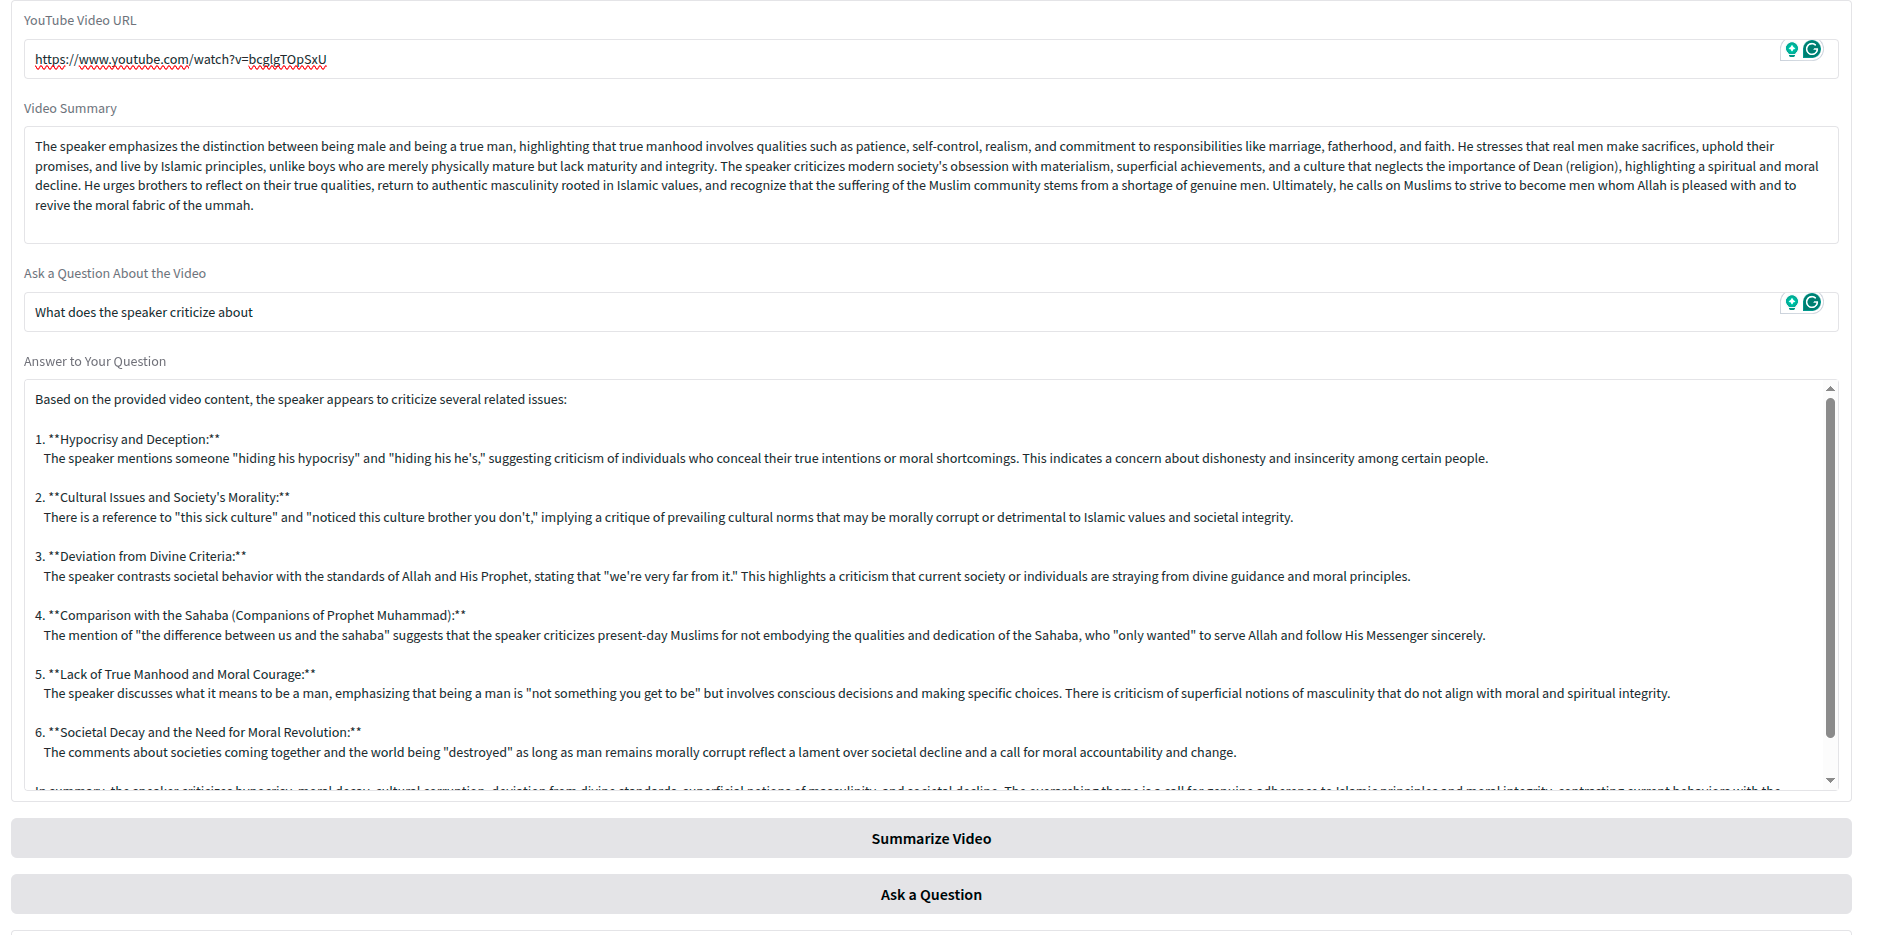